необходимо нормальное стаедартное распред


1\. Реализуйте обратное распространение ошибки для модели нейрона с квадратичной функцией потерь при условии, что на вход нейрону поступает вектор `inputs`. Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

In [ ]:
import torch

In [ ]:
import torch

inputs = torch.tensor([1.0, 2.0, 3.0], requires_grad=False)
weights = torch.tensor([0.5, 0.3, 0.2], requires_grad=True)
bias = torch.tensor(1.0, requires_grad=True)
target = torch.tensor(2.0)

output = torch.dot(inputs, weights) + bias
loss = (output - target)**2

loss.backward()

auto_grad_weights = weights.grad
auto_grad_bias = bias.grad


d_loss_d_output = 2 * (output - target)
d_output_d_weights = inputs
d_output_d_bias = 1.0

manual_grad_weights = d_loss_d_output * d_output_d_weights
manual_grad_bias = d_loss_d_output * d_output_d_bias

print("Автоматические градиенты (weights):", auto_grad_weights)
print("Ручные градиенты (weights):", manual_grad_weights)
print("Автоматические градиенты (bias):", auto_grad_bias)
print("Ручные градиенты (bias):", manual_grad_bias)

print(torch.allclose(auto_grad_weights, manual_grad_weights))
print(torch.allclose(auto_grad_bias, manual_grad_bias))


Автоматические градиенты (weights): tensor([1.4000, 2.8000, 4.2000])
Ручные градиенты (weights): tensor([1.4000, 2.8000, 4.2000], grad_fn=<MulBackward0>)
Автоматические градиенты (bias): tensor(1.4000)
Ручные градиенты (bias): tensor(1.4000, grad_fn=<MulBackward0>)
True
True


In [ ]:
class Linear:
    def __init__(self, n_neurons, n_features, bias: bool = False):
        self.w = torch.randn(n_features, n_neurons, requires_grad=True)
        self.b = torch.randn(1, n_neurons, requires_grad=True)

    def forward(self, inputs):
        y_pred = torch.mm(inputs, self.w) + self.b
        return y_pred

In [ ]:
def loss(y, y_pred):
  return ((y_pred - y)**2).mean()

def gradient(x, y, y_pred):
  return ((2* (y_pred - y)).unsqueeze(1) * x).mean(dim=0)

In [ ]:
inputs = torch.tensor([[1.0, 2.0, 3.0,3.0], [-4.0, 3.0, 9.0, -2.0],[1.0, -1.0, 3.0,-3.0]])
l = Linear(1,4)
y_pred = l.forward(inputs)
print(y_pred)

tensor([[-3.0795],
        [-0.7588],
        [ 0.8066]], grad_fn=<AddBackward0>)


In [ ]:
y_true = torch.tensor([[0,0.6,2.3]]).reshape(3,-1)
w = torch.normal(0,5,(10,1))
ll = loss(y_pred,y_true)
print(ll)

tensor(4.5199, grad_fn=<MeanBackward0>)


In [ ]:
ll.backward()

In [ ]:
l.w.grad
# dE/dw      dE/db
lg = gradient(inputs,y_pred,y_true)

In [ ]:
lg

tensor([-0.5748,  5.8279, 17.2983,  1.3604], grad_fn=<MeanBackward1>)

In [ ]:
l.w.grad,l.b.grad
# dE/dw      dE/db
lg = gradient(inputs,y_pred,y_true)

In [ ]:
lg

tensor([[  3.9544,   7.9089,  11.8633,  11.8633],
        [-15.8177,  11.8633,  35.5898,  -7.9089],
        [  3.9544,  -3.9544,  11.8633, -11.8633]], grad_fn=<MeanBackward1>)

In [ ]:
def gradient(x, y, y_pred):
  return (2* (y_pred - y)*x).mean(dim=0)

In [ ]:
l.w.grad,l.b.grad
# dE/dw      dE/db
lg = gradient(inputs,y_pred,y_true)
lg

tensor([  5.1693, -23.8485, -41.4956, -20.2930], grad_fn=<MeanBackward1>)

2\. Настройте модель нейрона, используя метод стохастического градиентного спуска

In [ ]:
import torch

learning_rate = 0.01
epochs = 100

inputs = torch.tensor([1.0, 2.0, 3.0], requires_grad=False)
weights = torch.tensor([0.5, 0.3, 0.2], requires_grad=True)
bias = torch.tensor(1.0, requires_grad=True)
target = torch.tensor(2.0)

for epoch in range(epochs):
    output = torch.dot(inputs, weights) + bias
    loss = (output - target)**2

    loss.backward()

    with torch.no_grad():
        weights -= learning_rate * weights.grad
        bias -= learning_rate * bias.grad

        weights.grad.zero_()
        bias.grad.zero_()

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

print("\nОбученные параметры:")
print(f"Weights: {weights.detach().numpy()}")
print(f"Bias: {bias.item():.4f}")
print(f"Final output: {output.item():.4f}")
print(f"Target: {target.item():.4f}")

Epoch 10, Loss: 0.0008
Epoch 20, Loss: 0.0000
Epoch 30, Loss: 0.0000
Epoch 40, Loss: 0.0000
Epoch 50, Loss: 0.0000
Epoch 60, Loss: 0.0000
Epoch 70, Loss: 0.0000
Epoch 80, Loss: 0.0000
Epoch 90, Loss: 0.0000
Epoch 100, Loss: 0.0000

Обученные параметры:
Weights: [0.4533333  0.20666666 0.06000001]
Bias: 0.9533
Final output: 2.0000
Target: 2.0000


<p class="task" id="1"></p>

1\. Реализуйте обратное распространение ошибки для модели нейрона с функцией потерь MSE при условии, что на вход нейрону поступает пакет (двумерный тензор) `inputs`. Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

$$\mathbf{X} = \begin{bmatrix}
x_{10} & x_{11} & \ldots & x_{1m} \\
x_{20} & x_{21} & \ldots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{k0} & x_{k1} & \ldots & x_{km} \\
\end{bmatrix}
\mathbf{Y} = \begin{bmatrix}
y_{1} \\
y_{2} \\
\vdots \\
y_{k} \\
\end{bmatrix}
\mathbf{W} = \begin{bmatrix}
w_{0} \\
w_{1} \\
\vdots \\
w_{m} \\
\end{bmatrix}$$

$$\hat{\mathbf{Y}} = \mathbf{X}\times \mathbf{W}$$

$$L = \frac{1}{k}\sum_{k}{(\hat{y_k}-y_k)^2}$$

$$\nabla_{\hat{\mathbf{Y}}} L=\begin{bmatrix}
\frac{\partial L}{\partial \hat{y_1}} \\
\frac{\partial L}{\partial \hat{y_2}} \\
\vdots \\
\frac{\partial L}{\partial \hat{y_k}} \\
\end{bmatrix} = \frac{2}{k}\begin{bmatrix}
\hat{y_1} - y_1 \\
\hat{y_2} - y_2 \\
\vdots \\
\hat{y_k} - y_k \\
\end{bmatrix}$$

$$\boldsymbol{\nabla_{\mathbf{W}} L = \mathbf{X}^T\nabla_{\hat{\mathbf{Y}}} L}$$

- [ ] Проверено на семинаре

PyTorch использует механизм автоматического дифференцирования (autograd), который работает только с тензорами, у которых установлен флаг requires_grad=True.

Флаг requires_grad=True указывает PyTorch, что для этого тензора нужно вычислять градиенты. Это необходимо для обучения модели, так как градиенты используются для обновления весов с помощью алгоритма обратного распространения ошибки.


Веса W должны быть согласованы по форме с входными данными X. Если X имеет размер (k x m), то W должен иметь размер (m x 1), чтобы результат умножения X @ W имел размер (k x 1) (один выход для каждого примера в пакете).

In [ ]:
import torch

k = 3
m = 2
X = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], requires_grad=False)
Y = torch.tensor([[1.0], [2.0], [3.0]], requires_grad=False)
W = torch.tensor([[0.5], [0.3]], requires_grad=True)

Y_hat = X @ W
loss = torch.mean((Y_hat - Y)**2)

d_loss_d_Y_hat = (2 / k) * (Y_hat - Y)
d_Y_hat_d_W = X
d_loss_d_W = X.T @ d_loss_d_Y_hat

loss.backward()
auto_grad_W = W.grad

manual_grad_W = d_loss_d_W

print("Автоматические градиенты (W):", auto_grad_W)
print("Ручные градиенты (W):", manual_grad_W)

assert torch.allclose(auto_grad_W, manual_grad_W), "Градиенты W не совпадают!"
print("Градиенты совпадают!")

Автоматические градиенты (W): tensor([[5.8000],
        [7.2000]])
Ручные градиенты (W): tensor([[5.8000],
        [7.2000]], grad_fn=<MmBackward0>)
Градиенты совпадают!


<p class="task" id="2"></p>

2\. Настройте модель нейрона, используя метод мини-пакетного градиентного спуска. Используйте обратное распространение ошибки, реализованное самостоятельно.

- [ ] Проверено на семинаре

W -= learning_rate * d_loss_d_W
bias -= learning_rate * d_loss_d_bias
Корректируем веса и смещение в сторону уменьшения ошибки.


np.random.permutation() — перемешиваем индексы строк, чтобы избежать заучивания на порядке данных.


coef=True — создаст настоящие коэффициенты coef, чтобы сравнить их с нашими обученными весами.

- print("Обученные веса (W):", W) # веса, которые модель нашла в процессе обучения. Они показывают, насколько сильно каждый из четырёх признаков влияет на предсказание. Чем больше значение, тем сильнее признак влияет на итоговый результат.
- print("Обученное смещение (bias):", bias)
print("Истинные коэффициенты (coef):", coef) # реальные значения весов, которые были использованы для генерации целевой переменной y. Они служат эталоном, насколько правильно обучилась модель.

In [ ]:
from sklearn.datasets import make_regression
import torch as th

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [ ]:
from sklearn.datasets import make_regression
import torch as th
import numpy as np

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

learning_rate = 0.01
num_epochs = 100
batch_size = 10

W = th.randn(X.shape[1], 1, requires_grad=False)
bias = th.zeros(1, requires_grad=False)

def mse_loss(y_pred, y_true):
    return th.mean((y_pred - y_true)**2)

for epoch in range(num_epochs):
    indices = np.random.permutation(X.shape[0])
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, X.shape[0], batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]

        y_pred = X_batch @ W + bias

        loss = mse_loss(y_pred, y_batch)

        d_loss_d_y_pred = (2 / batch_size) * (y_pred - y_batch)
        d_y_pred_d_W = X_batch
        d_y_pred_d_bias = th.ones_like(bias)

        d_loss_d_W = d_y_pred_d_W.T @ d_loss_d_y_pred
        d_loss_d_bias = th.sum(d_loss_d_y_pred * d_y_pred_d_bias)

        W -= learning_rate * d_loss_d_W
        bias -= learning_rate * d_loss_d_bias

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

print("Обученные веса (W):", W) # веса, которые модель нашла в процессе обучения. Они показывают, насколько сильно каждый из четырёх признаков влияет на предсказание. Чем больше значение, тем сильнее признак влияет на итоговый результат.
print("Обученное смещение (bias):", bias)
print("Истинные коэффициенты (coef):", coef) # реальные значения весов, которые были использованы для генерации целевой переменной y. Они служат эталоном, насколько правильно обучилась модель.

Epoch [10/100], Loss: 268.7824
Epoch [20/100], Loss: 8.7760
Epoch [30/100], Loss: 0.4125
Epoch [40/100], Loss: 0.0128
Epoch [50/100], Loss: 0.0008
Epoch [60/100], Loss: 0.0000
Epoch [70/100], Loss: 0.0000
Epoch [80/100], Loss: 0.0000
Epoch [90/100], Loss: 0.0000
Epoch [100/100], Loss: 0.0000
Обученные веса (W): tensor([[ 5.6375],
        [86.4722],
        [27.3407],
        [41.4819]])
Обученное смещение (bias): tensor([0.5000])
Истинные коэффициенты (coef): [ 5.63754967 86.47223763 27.34070719 41.48195023]


<p class="task" id="3"></p>

3\. Реализуйте обратное распространение ошибки для модели полносвязного слоя с функцией потерь MSE при условии, что на вход нейрону поступает пакет (двумерный тензор) `inputs`.  Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

$$\mathbf{X} = \begin{bmatrix}
x_{10} & x_{11} & \ldots & x_{1m} \\
x_{20} & x_{21} & \ldots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{k0} & x_{k1} & \ldots & x_{km} \\
\end{bmatrix}
\mathbf{Y} = \begin{bmatrix}
y_{1} \\
y_{2} \\
\vdots \\
y_{k} \\
\end{bmatrix}
\mathbf{W} = \begin{bmatrix}
w_{01} & w_{02} & \ldots & w_{0n} \\
w_{11} & w_{12} & \ldots & w_{1n} \\
\vdots & \vdots & \ddots & \vdots \\
w_{m1} & w_{m2} & \ldots & w_{mn} \\
\end{bmatrix}$$

$$\hat{\mathbf{Y}} = \mathbf{X}\times \mathbf{W}$$

$$\nabla_{\hat{\mathbf{Y}}} L = \begin{bmatrix}
\frac{\partial L}{\partial \hat{y_{11}}} & \ldots & \frac{\partial L}{\partial \hat{y_{1n}}} \\
\vdots & \vdots & \vdots \\
\frac{\partial L}{\partial \hat{y_{k1}}} & \ldots & \frac{\partial L}{\partial \hat{y_{kn}}} \\
\end{bmatrix}$$

$$\boldsymbol{\nabla_{\mathbf{W}} L = \mathbf{X}^T\times \nabla_{\hat{\mathbf{Y}}} L}$$
$$\boldsymbol{\nabla_{\mathbf{X}} L = \nabla_{\hat{\mathbf{Y}}} L\times \mathbf{W}^T}$$

- [ ] Проверено на семинаре

k, m, n = 5, 4, 3  # k - количество примеров, m - входные признаки, n - выходные признаки


In [ ]:
import torch

k, m, n = 5, 4, 3

X = torch.randn(k, m, requires_grad=True)
Y = torch.randn(k, n)

W = torch.randn(m, n, requires_grad=True)

Y_hat = X @ W

loss = torch.mean((Y_hat - Y) ** 2)

grad_Y_hat = (2 / k) * (Y_hat - Y)
grad_W_manual = X.T @ grad_Y_hat

loss.backward()

print("Градиент по W, рассчитанный вручную:")
print(grad_W_manual)
print("Градиент по W, рассчитанный PyTorch:")
print(W.grad)

print("Разница между градиентами по W:")
print(torch.allclose(grad_W_manual, W.grad))

grad_X_manual = grad_Y_hat @ W.T
print("Градиент по X, рассчитанный вручную:")
print(grad_X_manual)
print("Градиент по X, рассчитанный PyTorch:")
print(X.grad)

print("Разница между градиентами по X:")
print(torch.allclose(grad_X_manual, X.grad))



Градиент по W, рассчитанный вручную:
tensor([[-0.3974,  0.5323,  2.6398],
        [-2.9524,  0.7941,  1.7367],
        [ 2.6439, -3.5622, -2.5858],
        [ 4.6643, -0.2420, -4.7297]], grad_fn=<MmBackward0>)
Градиент по W, рассчитанный PyTorch:
tensor([[-0.1325,  0.1774,  0.8799],
        [-0.9841,  0.2647,  0.5789],
        [ 0.8813, -1.1874, -0.8619],
        [ 1.5548, -0.0807, -1.5766]])
Разница между градиентами по W:
False
Градиент по X, рассчитанный вручную:
tensor([[ 1.3036, -1.2783, -1.4351, -5.5931],
        [-1.0116,  1.4667, -1.7043,  1.8216],
        [-1.9977,  0.3803,  1.2236,  2.2740],
        [ 1.9745, -0.3877, -0.8802, -1.8173],
        [-0.7951,  0.8630, -0.4172,  1.8377]], grad_fn=<MmBackward0>)
Градиент по X, рассчитанный PyTorch:
tensor([[ 0.4345, -0.4261, -0.4784, -1.8644],
        [-0.3372,  0.4889, -0.5681,  0.6072],
        [-0.6659,  0.1268,  0.4079,  0.7580],
        [ 0.6582, -0.1292, -0.2934, -0.6058],
        [-0.2650,  0.2877, -0.1391,  0.6126]])
Разница 

<p class="task" id="4"></p>

4\. Настройте полносвязный слой, используя метод пакетного градиентного спуска. Используйте обратное распространение ошибки, реализованное самостоятельно.

- [ ] Проверено на семинаре

In [ ]:
from sklearn.datasets import make_regression
import torch as th

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [ ]:
import torch as th
from sklearn.datasets import make_regression

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

learning_rate = 0.01
num_epochs = 600

W = th.randn(X.shape[1], 1, requires_grad=False)
bias = th.zeros(1, requires_grad=False)

def mse_loss(y_pred, y_true):
    return th.mean((y_pred - y_true) ** 2)

for epoch in range(num_epochs):
    y_pred = X @ W + bias

    loss = mse_loss(y_pred, y)

    d_loss_d_y_pred = (2 / X.shape[0]) * (y_pred - y)
    d_y_pred_d_W = X
    d_y_pred_d_bias = th.ones_like(bias)

    d_loss_d_W = d_y_pred_d_W.T @ d_loss_d_y_pred
    d_loss_d_bias = th.sum(d_loss_d_y_pred)

    W -= learning_rate * d_loss_d_W
    bias -= learning_rate * d_loss_d_bias

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

print("Обученные веса (W):", W)
print("Обученное смещение (bias):", bias)
print("Истинные коэффициенты (coef):", coef)


Epoch [10/600], Loss: 6490.6992
Epoch [20/600], Loss: 4378.2832
Epoch [30/600], Loss: 2963.8704
Epoch [40/600], Loss: 2013.6981
Epoch [50/600], Loss: 1373.2119
Epoch [60/600], Loss: 939.9581
Epoch [70/600], Loss: 645.8279
Epoch [80/600], Loss: 445.4135
Epoch [90/600], Loss: 308.3459
Epoch [100/600], Loss: 214.2511
Epoch [110/600], Loss: 149.4133
Epoch [120/600], Loss: 104.5684
Epoch [130/600], Loss: 73.4363
Epoch [140/600], Loss: 51.7454
Epoch [150/600], Loss: 36.5784
Epoch [160/600], Loss: 25.9365
Epoch [170/600], Loss: 18.4445
Epoch [180/600], Loss: 13.1529
Epoch [190/600], Loss: 9.4040
Epoch [200/600], Loss: 6.7402
Epoch [210/600], Loss: 4.8421
Epoch [220/600], Loss: 3.4860
Epoch [230/600], Loss: 2.5147
Epoch [240/600], Loss: 1.8175
Epoch [250/600], Loss: 1.3158
Epoch [260/600], Loss: 0.9541
Epoch [270/600], Loss: 0.6929
Epoch [280/600], Loss: 0.5039
Epoch [290/600], Loss: 0.3669
Epoch [300/600], Loss: 0.2675
Epoch [310/600], Loss: 0.1952
Epoch [320/600], Loss: 0.1426
Epoch [330/600

<p class="task" id="5"></p>

5\. Используя решения предыдущих задач, создайте нейросеть и решите задачу регрессии.

Предлагаемая архитектура:
1. Полносвязный слой с 10 нейронами
2. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте прогнозы промежуточных моделей. Визуализируйте облако точек и промежуточные прогнозы не менее 4 промежуточных моделей. Визуализируйте прогнозы итоговой модели.

- [ ] Проверено на семинаре

In [ ]:
import torch as th

th.manual_seed(42)
X = th.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * th.rand(X.size())

Epoch [50/300], Loss: 0.0710
Epoch [100/300], Loss: 0.0524
Epoch [150/300], Loss: 0.0338
Epoch [200/300], Loss: 0.0201
Epoch [250/300], Loss: 0.0134
Epoch [300/300], Loss: 0.0109


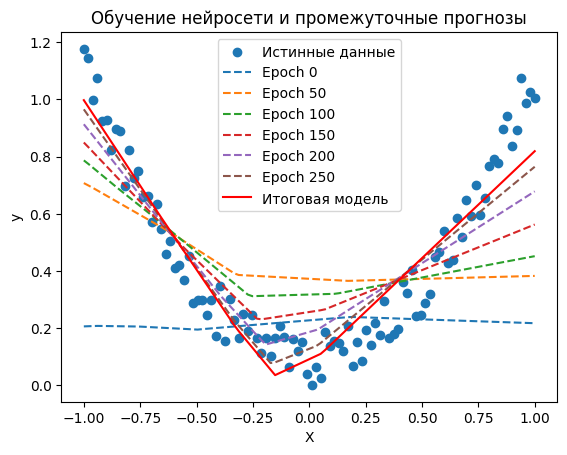

In [ ]:
import torch as th
import matplotlib.pyplot as plt

th.manual_seed(42)
X = th.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * th.rand(X.size())

learning_rate = 0.1
num_epochs = 300

class SimpleNN(th.nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden = th.nn.Linear(1, 10)
        self.output = th.nn.Linear(10, 1)

    def forward(self, x):
        x = th.relu(self.hidden(x))
        x = self.output(x)
        return x

model = SimpleNN()
criterion = th.nn.MSELoss()
optimizer = th.optim.SGD(model.parameters(), lr=learning_rate)

intermediate_predictions = []

for epoch in range(num_epochs):
    y_pred = model(X)

    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        intermediate_predictions.append((epoch, y_pred.detach().clone()))


    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

plt.scatter(X, y, label='Истинные данные')

for epoch, preds in intermediate_predictions:
    plt.plot(X, preds, '--', label=f'Epoch {epoch}')


final_preds = model(X).detach()
plt.plot(X, final_preds, 'r-', label='Итоговая модель')

plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('Обучение нейросети и промежуточные прогнозы')
plt.show()


<p class="task" id="6"></p>

6\. Cоздайте нейросеть и решите задачу регрессии из предыдущей задачи.

Предлагаемая архитектура:
1. Полносвязный слой с 10 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте прогнозы промежуточных моделей. Визуализируйте облако точек и промежуточные прогнозы не менее 4 промежуточных моделей. Визуализируйте прогнозы итоговой модели.

- [ ] Проверено на семинаре

 y_pred.detach().clone() - достать numpy array

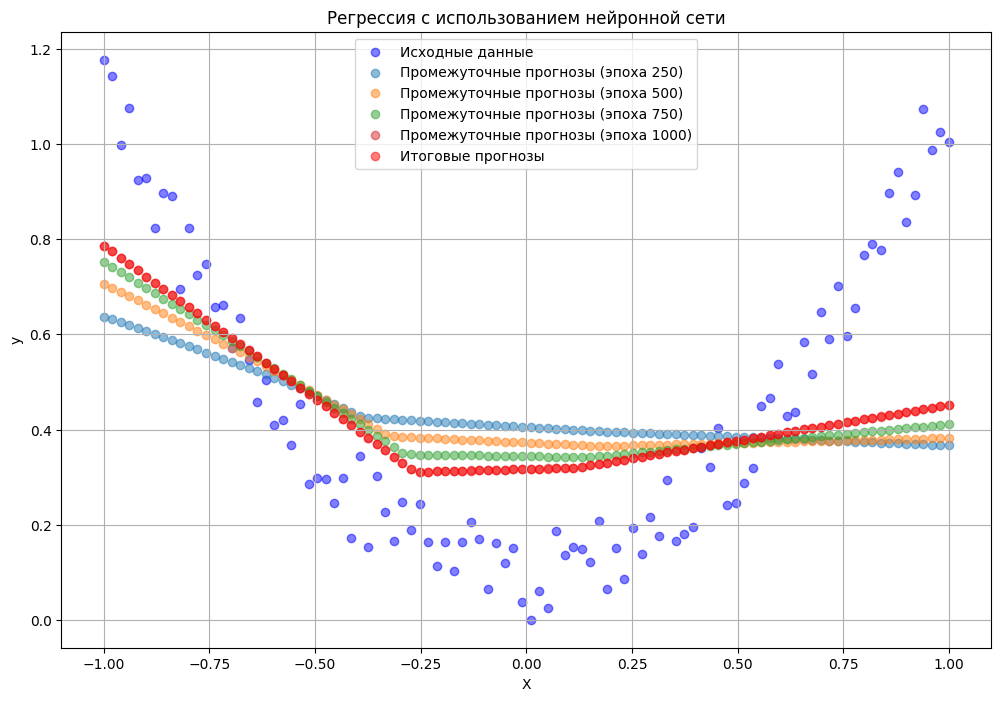

In [ ]:
import torch as th
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


th.manual_seed(42)


X = th.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * th.rand(X.size())


class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(1, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

def train_model(model, X, y, learning_rate=0.01, epochs=1000):
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    loss_function = nn.MSELoss()
    intermediate_predictions = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        predictions = model(X)

        loss = loss_function(predictions, y)

        loss.backward()
        optimizer.step()


        if (epoch + 1) % 250 == 0:
            intermediate_predictions.append(predictions.detach().numpy())

    return intermediate_predictions
model = SimpleNN()
intermediate_predictions = train_model(model, X, y, learning_rate=0.01, epochs=1000)
plt.figure(figsize=(12, 8))
plt.scatter(X.numpy(), y.numpy(), color='blue', label='Исходные данные', alpha=0.5)
for i, preds in enumerate(intermediate_predictions):
    plt.scatter(X.numpy(), preds, label=f'Промежуточные прогнозы (эпоха {250 * (i + 1)})', alpha=0.5)

final_predictions = model(X).detach().numpy()
plt.scatter(X.numpy(), final_predictions, color='red', label='Итоговые прогнозы', alpha=0.5)

plt.title('Регрессия с использованием нейронной сети')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()